# CV Lab 7

## 1) Create a fully-connected model to
## recognize fashion mnist class
## Criteria:
## - Fully connected
## - No overfitting
## - Draw confusion matri

In [1]:
import tensorflow_datasets as tfds
import tensorflow as tf
import math
import numpy as np
import matplotlib.pyplot as plt
import time

## Importing and exploring dataset

In [2]:
dataset, metadata = tfds.load('cifar10', as_supervised=True, with_info=True)
train, test = dataset['train'], dataset['test']

In [3]:
print(metadata.features['label'].names)
print(len(metadata.features['label'].names))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
10


In [4]:
print(len(train))
print(len(test))

50000
10000


## Normalizing images' values for better calculation efficiency

In [5]:
def normalize(images, labels):
  images = tf.cast(images,dtype=float)
  images /= 255
  return images, labels

train =  train.map(normalize)
test  =  test.map(normalize)

#train =  train.cache()
#test  =  test.cache()

## Exploring images after normalizing

(32, 32, 3)
(32, 32, 3)
(32, 32, 3)
(32, 32, 3)
(32, 32, 3)
(32, 32, 3)
(32, 32, 3)
(32, 32, 3)
(32, 32, 3)
(32, 32, 3)


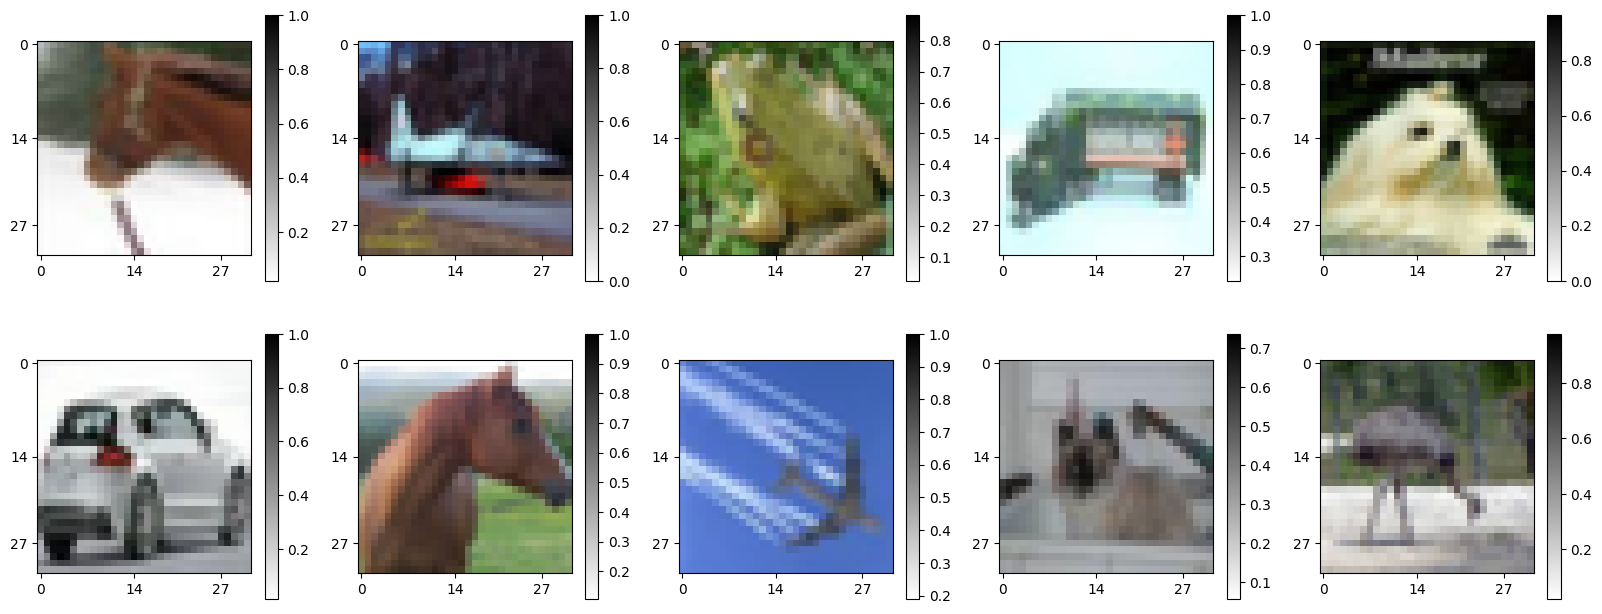

In [6]:
plt.figure(figsize=(20,20))

i = 0

for (image, label) in test.take(10):
    print(image.shape)
    plt.subplot(5,5,i+1)
    plt.xticks([0,14,27])
    plt.yticks([0,14,27])
    plt.imshow(image, cmap=plt.cm.binary)
    plt.colorbar()
    i += 1

plt.show()

## Building Model

In [7]:
batchSize = 1000

train = train.cache().repeat().shuffle(60000).batch(batchSize)
test = test.cache().batch(batchSize)

print (train)

<_BatchDataset element_spec=(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


In [8]:
model = tf.keras.Sequential(
    [
    tf.keras.layers.Conv2D(32 , (3,3) , padding='same' ,activation=tf.nn.relu , input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2) , strides=2),

    tf.keras.layers.Conv2D(64 , (3,3) , padding='same',activation=tf.nn.relu),
    tf.keras.layers.MaxPooling2D((2,2) ),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10)
    ]
)

In [9]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [ ]:
t = time.time()
hist = model.fit(train, epochs=10, steps_per_epoch=math.ceil(60000/batchSize))
print (str.format("Training took: {:0.2f} Sec", time.time() - t))

Epoch 1/10
60/60 [==============================] - 134s 2s/step - loss: 1.7676 - accuracy: 0.3701
Epoch 2/10
60/60 [==============================] - 114s 2s/step - loss: 1.4120 - accuracy: 0.5012
Epoch 3/10
60/60 [==============================] - 112s 2s/step - loss: 1.2778 - accuracy: 0.5525
Epoch 4/10
60/60 [==============================] - 113s 2s/step - loss: 1.1810 - accuracy: 0.5878
Epoch 5/10
60/60 [==============================] - 118s 2s/step - loss: 1.1157 - accuracy: 0.6132
Epoch 6/10
26/60 [============>.................] - ETA: 1:07 - loss: 1.0902 - accuracy: 0.6206

In [ ]:
model.summary()

## Evaluating model

In [ ]:
test_loss, test_accuracy = model.evaluate(test, steps=math.ceil(10000/batchSize))
print('Loss on test dataset:', test_loss)
print('Accuracy on test dataset:', test_accuracy)

In [ ]:
hist.history['accuracy']

In [ ]:
plt.xlabel('Epoch Number')
plt.plot(hist.history['loss'] ,label='loss')
plt.plot(hist.history['accuracy'] ,label='accuracy')
plt.legend()

In [ ]:
plt.xlabel('Epoch Number')
plt.ylabel("accuracy value")
plt.plot(hist.history['accuracy']);

## Confusion Matrix

In [ ]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
train, test = dataset['train'], dataset['test']

validation_batches = test.batch(batchSize)
pred = model.predict(validation_batches)
pred = np.argmax(pred,axis=1)
true = tf.concat([y for x,y in validation_batches],axis=0)

mat = confusion_matrix(true,pred)
plot_confusion_matrix(conf_mat=mat,figsize=(8,8), class_names=metadata.features['label'].names)